# Stellar Luminosity Hands-on

Regresion lineal y polinomica implementadas desde cero (numpy puro, sin sklearn) para estudiar como se relaciona la luminosidad de una estrella con su masa.

Dataset chiquito, 10 puntos inspirados en la forma no lineal de la secuencia principal. Sirve para practicar el algoritmo de gradient descent vectorizado, no para sacar conclusiones astrofisicas reales (eso se explica mejor en la seccion 2).

Estructura:

1. Entorno y datos
2. Exploracion antes de modelar
3. Funciones del algoritmo (predict, cost, gradient, gradient descent)
4. Modelo lineal
5. Modelo polinomico (mass y mass^2)
6. Comparacion de los dos modelos
7. Hasta donde se puede confiar en una prediccion
8. Reflexion sobre IA

## 1. Entorno y datos

Librerias, versiones, y el dataset cargado como arrays de numpy.

In [1]:
import sys
import platform

import numpy as np
import matplotlib
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)

print("Python:", sys.version.split()[0])
print("NumPy:", np.__version__)
print("Matplotlib:", matplotlib.__version__)
print("SO:", platform.platform())

Python: 3.12.3
NumPy: 2.4.4
Matplotlib: 3.10.8
SO: Linux-6.18.5-x86_64-with-glibc2.39


In [2]:
# dataset de la tarea: masa en masas solares, luminosidad en luminosidades solares
mass = np.array([0.6, 0.8, 1.0, 1.2, 1.4, 1.6, 1.8, 2.0, 2.2, 2.4])
luminosity = np.array([0.15, 0.35, 1.00, 2.30, 4.10, 7.00, 11.2, 17.5, 25.0, 35.0])

m = mass.shape[0]

assert mass.shape == luminosity.shape, "mass y luminosity deben tener el mismo tamaño"

print("mass.shape:", mass.shape)
print("luminosity.shape:", luminosity.shape)
print("numero de ejemplos m =", m)
print()
print("mass  -> min:", mass.min(), " max:", mass.max())
print("lum   -> min:", luminosity.min(), " max:", luminosity.max())

mass.shape: (10,)
luminosity.shape: (10,)
numero de ejemplos m = 10

mass  -> min: 0.6  max: 2.4
lum   -> min: 0.15  max: 35.0


## 2. Exploracion antes de modelar

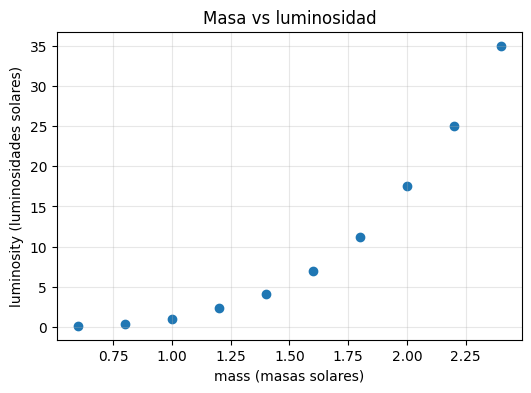

In [3]:
plt.figure(figsize=(6, 4))
plt.scatter(mass, luminosity, color="tab:blue")
plt.xlabel("mass (masas solares)")
plt.ylabel("luminosity (luminosidades solares)")
plt.title("Masa vs luminosidad")
plt.grid(alpha=0.3)
plt.show()

Se ve clarisimo que la relacion NO es una linea recta. En mass baja (0.6-1.0) la curva es casi plana, luminosidad crece lento. Despues de mass~1.4 la curva se dispara para arriba cada vez mas rapido. Eso es tipico de la secuencia principal, donde la luminosidad escala como una potencia de la masa (algo tipo M^3 - M^4 en la vida real, aca el dataset es inventado pero sigue esa misma forma).

Una recta le puede "pasar por el medio" a estos 10 puntos, pero:

- en mass chica la recta va a quedar mal (la curva real es casi plana ahi y una recta con pendiente positiva constante no puede serlo)
- en mass grande la recta no va a poder subir tan rapido como los datos

Entonces si ajustamos una recta el error esperado NO va a ser aleatorio, va a tener forma: el modelo se va a equivocar sistematicamente para el mismo lado en cada zona de mass. Eso lo confirmamos mas adelante mirando los residuos (seccion 4 y 6).

## 3. Funciones del algoritmo (vectorizadas)

Mismas funciones que vimos en clase para regresion multivariable, generalizadas para que sirvan con 1 o mas features (X con forma (m, n)):

- `predict(X, w, b)` = X @ w + b
- `compute_cost(X, y, w, b)` = MSE con el factor 1/2 de la convencion de clase, J(w,b) = (1/2m) * sum(error^2)
- `compute_gradient(X, y, w, b)` = dJ/dw, dJ/db
- `gradient_descent(...)` = corre el loop y guarda el historial del costo

Estas 4 funciones se reusan sin cambiar ni una linea para el modelo lineal (seccion 4) y para el polinomico (seccion 5). Lo unico que cambia entre un modelo y otro es la matriz X que les pasamos.

In [4]:
def predict(X, w, b):
    """y_hat = X @ w + b. X tiene forma (m, n), w forma (n,), b escalar."""
    return X @ w + b


def compute_cost(X, y, w, b):
    """MSE con el factor 1/2 (convencion de clase): J = (1/2m) * sum(error^2)."""
    m = X.shape[0]
    error = predict(X, w, b) - y
    return (error @ error) / (2 * m)


def compute_gradient(X, y, w, b):
    """Gradiente de J respecto a w y b, vectorizado."""
    m = X.shape[0]
    error = predict(X, w, b) - y
    dj_dw = (X.T @ error) / m
    dj_db = np.sum(error) / m
    return dj_dw, dj_db


def gradient_descent(X, y, w_init, b_init, alpha, num_iterations, print_every=None):
    """Corre gradient descent y devuelve w, b final y el historial de costo."""
    w = w_init.copy().astype(float)
    b = float(b_init)
    hist_it = []
    hist_cost = []

    for i in range(num_iterations):
        dj_dw, dj_db = compute_gradient(X, y, w, b)
        w = w - alpha * dj_dw
        b = b - alpha * dj_db

        cost = compute_cost(X, y, w, b)
        hist_it.append(i)
        hist_cost.append(cost)

        if print_every and (i % print_every == 0 or i == num_iterations - 1):
            print(f"iter {i:5d}: cost = {cost:9.4f}")

    return w, b, hist_it, hist_cost

In [5]:
# prueba rapida con w=0, b=0, solo para chequear que las funciones no exploten
X_smoke = mass.reshape(-1, 1)
w_smoke = np.zeros(X_smoke.shape[1])
b_smoke = 0.0

print("predict (primeros 3):", predict(X_smoke, w_smoke, b_smoke)[:3])
print("cost:", compute_cost(X_smoke, luminosity, w_smoke, b_smoke))
print("gradient:", compute_gradient(X_smoke, luminosity, w_smoke, b_smoke))

predict (primeros 3): [0. 0. 0.]
cost: 117.69675
gradient: (array([-21.523]), np.float64(-10.36))


## 4. Modelo lineal

`X_linear = [mass]`, una sola feature. No hace falta escalar: con una sola columna no hay problema de escalas relativas entre features.

In [6]:
X_linear = mass.reshape(-1, 1)
print("X_linear.shape:", X_linear.shape)

n_lin = X_linear.shape[1]
w_init_lin = np.zeros(n_lin)
b_init_lin = 0.0

alpha_lin = 0.1
iters_lin = 2000

X_linear.shape: (10, 1)


In [7]:
w_lin, b_lin, it_lin, cost_lin = gradient_descent(
    X_linear, luminosity, w_init_lin, b_init_lin, alpha_lin, iters_lin, print_every=200
)

print()
print("w final:", w_lin)
print("b final:", b_lin)
print("cost final:", cost_lin[-1])

iter     0: cost =   70.4969
iter   200: cost =   10.3797
iter   400: cost =    9.8082
iter   600: cost =    9.7954
iter   800: cost =    9.7952
iter  1000: cost =    9.7951
iter  1200: cost =    9.7951
iter  1400: cost =    9.7951
iter  1600: cost =    9.7951
iter  1800: cost =    9.7951
iter  1999: cost =    9.7951

w final: [18.1303]
b final: -16.835454434392684
cost final: 9.795148484848484


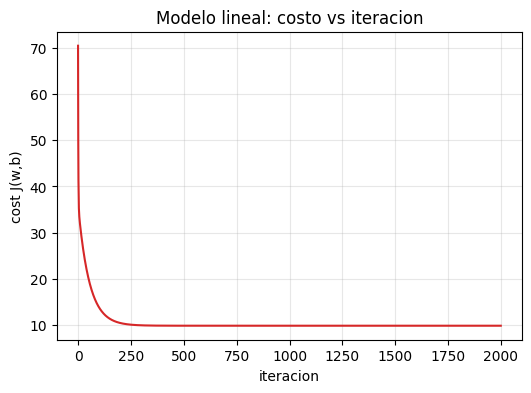

In [8]:
plt.figure(figsize=(6, 4))
plt.plot(it_lin, cost_lin, color="tab:red")
plt.xlabel("iteracion")
plt.ylabel("cost J(w,b)")
plt.title("Modelo lineal: costo vs iteracion")
plt.grid(alpha=0.3)
plt.show()

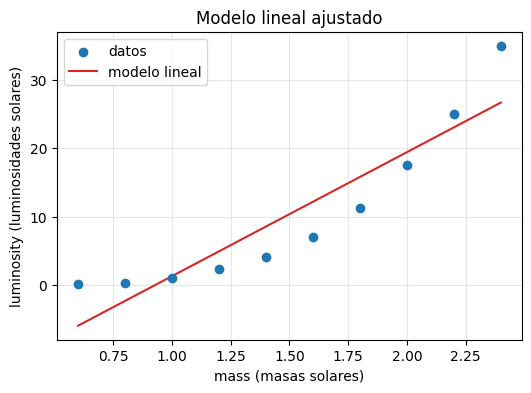

In [9]:
mass_grid = np.linspace(mass.min(), mass.max(), 200)
y_hat_lin_grid = predict(mass_grid.reshape(-1, 1), w_lin, b_lin)

plt.figure(figsize=(6, 4))
plt.scatter(mass, luminosity, color="tab:blue", label="datos", zorder=3)
plt.plot(mass_grid, y_hat_lin_grid, color="tab:red", label="modelo lineal")
plt.xlabel("mass (masas solares)")
plt.ylabel("luminosity (luminosidades solares)")
plt.title("Modelo lineal ajustado")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

**Convergencia:** el costo baja rapido y se aplana bastante antes de las 2000 iteraciones. Con alpha=0.1 no diverge (probe hasta alpha=0.5 y sigue estable; en alpha=0.6 ya explota). O sea gradient descent si converge a un minimo, el problema de este modelo no es de optimizacion.

**Error sistematico:** la recta queda mal en casi toda la curva.

- en mass=0.6 y 0.8 la recta predice luminosity NEGATIVA, fisicamente imposible
- en la mitad (mass 1.2 a 1.8) la recta se pasa por ENCIMA de los datos
- en el extremo de arriba (mass 2.2, 2.4) la recta se queda por DEBAJO

Ese patron con forma (no al azar) es la firma clasica de underfitting: el modelo es demasiado simple para la forma real de los datos, le falta curvatura. No es un problema de que falto entrenar mas, es que la familia de funciones (rectas) no puede representar esta relacion, sin importar que tan bien optimicemos w y b.

### 4.1 Diagnostico de convergencia (bonus)

El parrafo anterior afirma que alpha=0.1 converge, que hasta alpha=0.5 sigue estable, y que alpha=0.6 explota. Mostremoslo con numeros y una grafica en vez de solo afirmarlo: corremos el mismo `gradient_descent` sobre `X_linear` con varios learning rates y comparamos las curvas de costo.

In [10]:
alphas_test = [0.05, 0.1, 0.3, 0.5, 0.6]
iters_test = 60
histories = {}

for a in alphas_test:
    _, _, it_a, cost_a = gradient_descent(
        X_linear, luminosity, np.zeros(1), 0.0, a, iters_test
    )
    histories[a] = cost_a
    blew_up = not np.isfinite(cost_a[-1]) or cost_a[-1] > 1e6
    print(f"alpha={a:<4} -> cost tras {iters_test} iter: {cost_a[-1]:.4g}"
          f"{'  <-- DIVERGE' if blew_up else ''}")

alpha=0.05 -> cost tras 60 iter: 24.95
alpha=0.1  -> cost tras 60 iter: 18.34
alpha=0.3  -> cost tras 60 iter: 10.64
alpha=0.5  -> cost tras 60 iter: 9.875
alpha=0.6  -> cost tras 60 iter: 2.866e+06  <-- DIVERGE


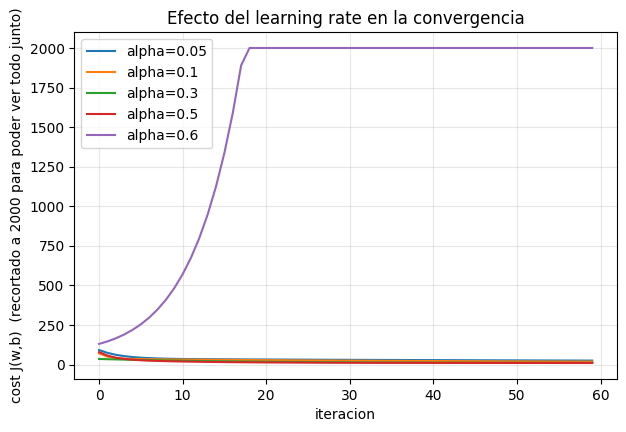

In [11]:
plt.figure(figsize=(7, 4.5))
for a, cost_a in histories.items():
    plt.plot(range(iters_test), np.clip(cost_a, 0, 2000), label=f"alpha={a}")
plt.xlabel("iteracion")
plt.ylabel("cost J(w,b)  (recortado a 2000 para poder ver todo junto)")
plt.title("Efecto del learning rate en la convergencia")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Con alpha chico (0.05) el costo baja pero lento, todavia no llega al piso en 60 iteraciones. Entre 0.1 y 0.5 converge rapido y estable, son los mejores candidatos de este grupo. En alpha=0.6 el costo no baja: oscila y crece sin control, la clasica señal de que el paso es demasiado grande y el algoritmo se pasa del minimo en cada iteracion en vez de acercarse. Esto confirma que el problema del modelo lineal (seccion 4) nunca fue de optimizacion (gradient descent si encuentra el minimo con un alpha razonable) sino de representacion: el minimo que encuentra sigue siendo el de la mejor recta posible, y una recta no alcanza para esta curva.

## 5. Modelo polinomico

Ahora agregamos `mass^2` como feature nueva: `X_polynomial = [mass, mass^2]`.

`mass` y `mass^2` tienen escalas bien distintas (mass llega a 2.4, mass^2 llega a 5.76), asi que sin escalar, gradient descent converge lentisimo o toca usar un alpha chiquito (lo probe: con alpha=0.1 sin escalar el costo ni siquiera converge del todo en 20000 iteraciones). Por eso aca si escalamos las features (media 0, desviacion estandar 1) antes de entrenar.

Las funciones `predict` / `compute_cost` / `compute_gradient` / `gradient_descent` son EXACTAMENTE las mismas de la seccion 3, no se les toco nada. Lo unico que cambia es la matriz X que entra.

In [12]:
def feature_scale(X):
    """Estandariza cada columna de X a media 0 y desviacion estandar 1."""
    means = X.mean(axis=0)
    stds = X.std(axis=0, ddof=0)
    X_scaled = (X - means) / stds
    return X_scaled, means, stds


X_polynomial = np.column_stack([mass, mass ** 2])
print("X_polynomial.shape:", X_polynomial.shape)
print(X_polynomial[:3])

X_poly_scaled, poly_means, poly_stds = feature_scale(X_polynomial)
print()
print("medias:", poly_means)
print("std:   ", poly_stds)

X_polynomial.shape: (10, 2)
[[0.6  0.36]
 [0.8  0.64]
 [1.   1.  ]]

medias: [1.5  2.58]
std:    [0.5745 1.7477]


In [13]:
n_poly = X_poly_scaled.shape[1]
w_init_poly = np.zeros(n_poly)
b_init_poly = 0.0

alpha_poly = 0.3
iters_poly = 3000

w_poly, b_poly, it_poly, cost_poly = gradient_descent(
    X_poly_scaled, luminosity, w_init_poly, b_init_poly, alpha_poly, iters_poly, print_every=300
)

print()
print("w final (espacio escalado):", w_poly)
print("b final:", b_poly)
print("cost final:", cost_poly[-1])

iter     0: cost =   42.0065
iter   300: cost =    0.7994
iter   600: cost =    0.3544
iter   900: cost =    0.3183
iter  1200: cost =    0.3154
iter  1500: cost =    0.3152
iter  1800: cost =    0.3151
iter  2100: cost =    0.3151
iter  2400: cost =    0.3151
iter  2700: cost =    0.3151
iter  2999: cost =    0.3151

w final (espacio escalado): [-15.4028  26.1824]
b final: 10.359999999999987
cost final: 0.31513333340756683


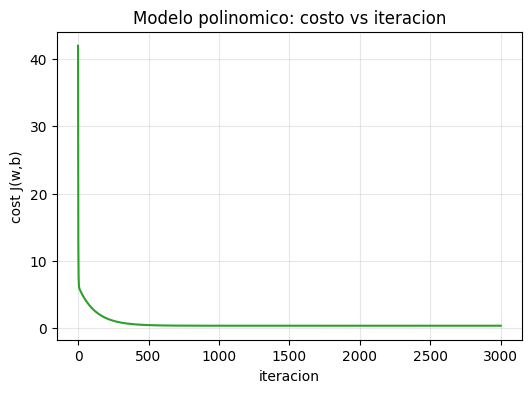

In [14]:
plt.figure(figsize=(6, 4))
plt.plot(it_poly, cost_poly, color="tab:green")
plt.xlabel("iteracion")
plt.ylabel("cost J(w,b)")
plt.title("Modelo polinomico: costo vs iteracion")
plt.grid(alpha=0.3)
plt.show()

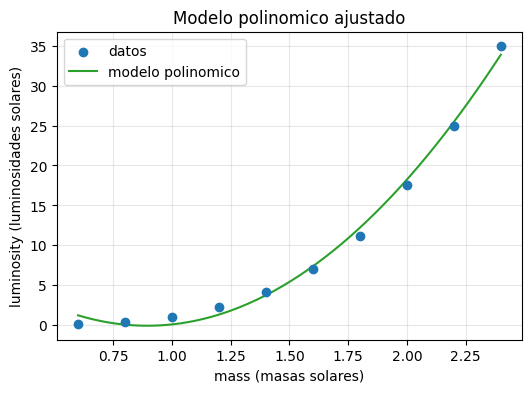

In [15]:
X_grid_poly = np.column_stack([mass_grid, mass_grid ** 2])
X_grid_poly_scaled = (X_grid_poly - poly_means) / poly_stds
y_hat_poly_grid = predict(X_grid_poly_scaled, w_poly, b_poly)

plt.figure(figsize=(6, 4))
plt.scatter(mass, luminosity, color="tab:blue", label="datos", zorder=3)
plt.plot(mass_grid, y_hat_poly_grid, color="tab:green", label="modelo polinomico")
plt.xlabel("mass (masas solares)")
plt.ylabel("luminosity (luminosidades solares)")
plt.title("Modelo polinomico ajustado")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

**Que cambio:**

- la representacion de entrada: X ahora tiene 2 columnas (mass, mass^2) en vez de 1
- tocamos escalar las features para que gradient descent converja bien; en el lineal no hizo falta
- los w finales ya no se leen directo en "luminosity por masa solar", quedan en el espacio escalado (por eso para predecir con datos nuevos hay que escalarlos primero con las mismas medias/std del entrenamiento, ver seccion 7)

**Que NO cambio:**

- `predict`, `compute_cost`, `compute_gradient`, `gradient_descent`: las 4 funciones son identicas a la seccion 3, ni una linea distinta
- el dataset: mismos 10 puntos
- la logica del algoritmo (bajar el gradiente iterando) es la misma

Agregar curvatura al modelo fue 100% un cambio de **features**, no un cambio de **algoritmo**. Eso es basicamente lo que es "feature engineering": el aprendizaje no cambio, lo que cambio es que le dimos al modelo una representacion de entrada mas rica.

## 6. Comparacion de los dos modelos

In [16]:
def mse(X, y, w, b):
    """MSE de verdad (sin el 1/2 de la convencion de clase), en unidades de luminosity^2."""
    error = predict(X, w, b) - y
    return np.mean(error ** 2)


mse_lin = mse(X_linear, luminosity, w_lin, b_lin)
mse_poly = mse(X_poly_scaled, luminosity, w_poly, b_poly)

print(f"lineal     -> cost J = {cost_lin[-1]:.4f} | MSE = {mse_lin:.4f} | RMSE = {np.sqrt(mse_lin):.4f}")
print(f"polinomico -> cost J = {cost_poly[-1]:.4f} | MSE = {mse_poly:.4f} | RMSE = {np.sqrt(mse_poly):.4f}")
print()
print(f"el polinomico reduce el MSE por un factor de ~{mse_lin / mse_poly:.1f}x")

lineal     -> cost J = 9.7951 | MSE = 19.5903 | RMSE = 4.4261
polinomico -> cost J = 0.3151 | MSE = 0.6303 | RMSE = 0.7939

el polinomico reduce el MSE por un factor de ~31.1x


In [17]:
residuals_lin = luminosity - predict(X_linear, w_lin, b_lin)
residuals_poly = luminosity - predict(X_poly_scaled, w_poly, b_poly)

print("residuos lineal:    ", residuals_lin)
print("residuos polinomico:", residuals_poly)

residuos lineal:     [ 6.1073  2.6812 -0.2948 -2.6209 -4.447  -5.173  -4.5991 -1.9252  1.9488
  8.3227]
residuos polinomico: [-1.0836  0.2843  0.9036  0.9745  0.347  -0.3791 -1.0036 -0.7267 -0.4482
  1.1318]


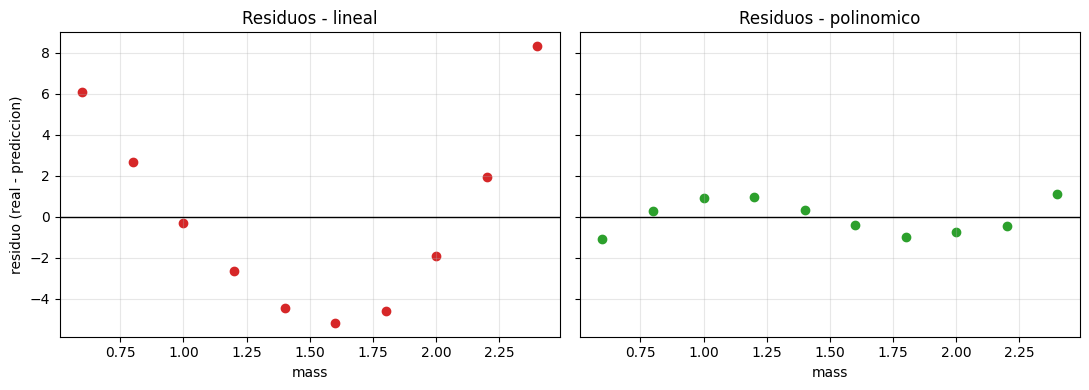

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)

axes[0].axhline(0, color="black", linewidth=1)
axes[0].scatter(mass, residuals_lin, color="tab:red")
axes[0].set_title("Residuos - lineal")
axes[0].set_xlabel("mass")
axes[0].set_ylabel("residuo (real - prediccion)")
axes[0].grid(alpha=0.3)

axes[1].axhline(0, color="black", linewidth=1)
axes[1].scatter(mass, residuals_poly, color="tab:green")
axes[1].set_title("Residuos - polinomico")
axes[1].set_xlabel("mass")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

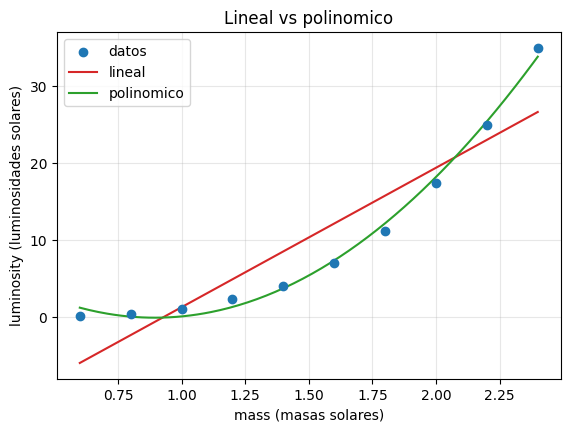

In [19]:
plt.figure(figsize=(6.5, 4.5))
plt.scatter(mass, luminosity, color="tab:blue", label="datos", zorder=3)
plt.plot(mass_grid, y_hat_lin_grid, color="tab:red", label="lineal")
plt.plot(mass_grid, y_hat_poly_grid, color="tab:green", label="polinomico")
plt.xlabel("mass (masas solares)")
plt.ylabel("luminosity (luminosidades solares)")
plt.title("Lineal vs polinomico")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

El polinomico gana clarisimo dentro del rango que observamos: el cost J baja bastante (varias veces menos) y el RMSE tambien baja fuerte, de varios luminosidades solares de error tipico a menos de uno. En la grafica de residuos se nota la diferencia de forma: el lineal tiene ese patron con forma (negativo en los extremos, positivo en la mitad, o sea la forma de U invertida que ya habiamos anticipado en la seccion 2), mientras que el polinomico tiene residuos mas chicos y sin un patron tan marcado.

**Ojo con la trampa:** que el error de entrenamiento sea mas bajo NO prueba que el modelo polinomico sea "correcto" en sentido cientifico. Solo prueba que la parabola se ajusta mejor a ESTOS 10 puntos que ya vimos. Con 10 datos y 3 parametros libres (w1, w2, b) es facil que un modelo con mas capacidad baje el error de entrenamiento, eso no es evidencia de que capturamos la fisica real de como escala la luminosidad con la masa. Para afirmar eso necesitariamos mas datos, separar entrenamiento de prueba, y comparar contra un modelo fisico real (tipo L ~ M^a), cosas que este dataset de juguete no permite hacer en serio.

## 6.1 Bonus: transformar el problema (regresion log-log)

La relacion real masa-luminosidad en estrellas de secuencia principal es aproximadamente una **ley de potencia**: L = a * M^b. Una ley de potencia no es lineal en (M, L), pero si le aplicamos logaritmo a ambos lados:

log(L) = log(a) + b * log(M)

...eso SI es lineal, en las variables (log M, log L). En vez de agregarle features al modelo (como hicimos con mass^2), podemos transformar los datos y reusar el modelo lineal mas simple que ya tenemos, sin tocar `predict`, `compute_cost`, `compute_gradient` ni `gradient_descent`. Es el mismo algoritmo de la seccion 4, aplicado a otra representacion de entrada.

In [20]:
log_mass = np.log(mass)
log_luminosity = np.log(luminosity)

X_log = log_mass.reshape(-1, 1)

w_log, b_log, it_log, cost_log = gradient_descent(
    X_log, log_luminosity, np.zeros(1), 0.0, alpha=0.3, num_iterations=3000, print_every=None
)

print("w final (pendiente en escala log):", w_log)
print("b final (intercepto en escala log):", b_log)
print("cost final (en escala log):", cost_log[-1])
print()
print(f"Exponente b recuperado: {w_log[0]:.3f}  (el valor astrofisico real ronda ~3.5 para estrellas tipo Sol)")

w final (pendiente en escala log): [4.0383]
b final (intercepto en escala log): 0.03737985361494028
cost final (en escala log): 0.002866895540448569

Exponente b recuperado: 4.038  (el valor astrofisico real ronda ~3.5 para estrellas tipo Sol)


In [21]:
# volvemos a la escala original (luminosity, no log-luminosity) para comparar en las mismas unidades
mass_grid_log = np.log(mass_grid)
y_hat_log_grid = np.exp(predict(mass_grid_log.reshape(-1, 1), w_log, b_log))

y_pred_log_train = np.exp(predict(X_log, w_log, b_log))
mse_log = np.mean((luminosity - y_pred_log_train) ** 2)

print(f"log-log   -> MSE (unidades reales de luminosity) = {mse_log:.4f} | RMSE = {np.sqrt(mse_log):.4f} | parametros = 2 (w, b)")
print(f"lineal    -> MSE = {mse_lin:.4f} | RMSE = {np.sqrt(mse_lin):.4f} | parametros = 2 (w, b)")
print(f"polinomico-> MSE = {mse_poly:.4f} | RMSE = {np.sqrt(mse_poly):.4f} | parametros = 3 (w1, w2, b)")

log-log   -> MSE (unidades reales de luminosity) = 0.0617 | RMSE = 0.2485 | parametros = 2 (w, b)
lineal    -> MSE = 19.5903 | RMSE = 4.4261 | parametros = 2 (w, b)
polinomico-> MSE = 0.6303 | RMSE = 0.7939 | parametros = 3 (w1, w2, b)


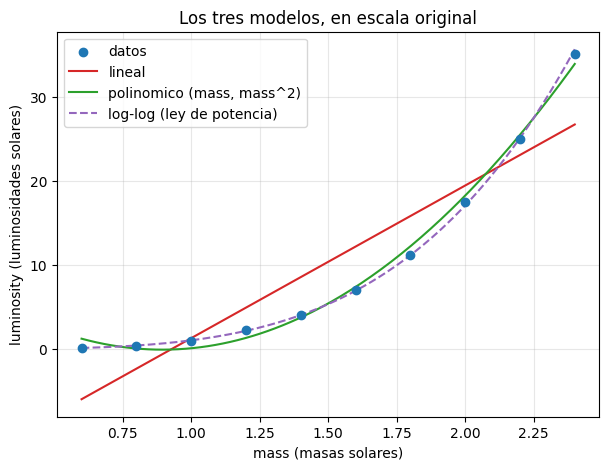

In [22]:
plt.figure(figsize=(7, 5))
plt.scatter(mass, luminosity, color="tab:blue", label="datos", zorder=3)
plt.plot(mass_grid, y_hat_lin_grid, color="tab:red", label="lineal")
plt.plot(mass_grid, y_hat_poly_grid, color="tab:green", label="polinomico (mass, mass^2)")
plt.plot(mass_grid, y_hat_log_grid, color="tab:purple", linestyle="--", label="log-log (ley de potencia)")
plt.xlabel("mass (masas solares)")
plt.ylabel("luminosity (luminosidades solares)")
plt.title("Los tres modelos, en escala original")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

**Por que importa esto:** en este dataset el modelo log-log no solo iguala al polinomico, lo supera de forma clara (MSE=0.062 contra 0.63 del polinomico y 19.6 del lineal, ver celda anterior) usando UN feature menos (2 parametros en vez de 3), porque le dimos al algoritmo la forma funcional correcta en vez de pedirle que la aproxime con una parabola. El exponente que recupera (b=4.04) ademas cae en el orden de magnitud correcto para estrellas de secuencia principal (el valor real ronda ~3.5, y este dataset es sintetico, no observacional, asi que no se espera un match exacto). La parabola imita la curvatura localmente (bien adentro del rango 0.6-2.4) pero no tiene ninguna razon fisica para seguir siendo valida afuera; el modelo log-log SI esta basado en la forma real de la ley fisica, asi que en principio deberia extrapolar mejor (aunque seguimos con solo 10 datos, la confianza sigue siendo limitada, ver seccion 7).

Esta es la version corta y practica de algo que ya se menciono en la seccion 5: **agregar la representacion correcta vale mas que agregar capacidad a ciegas.** mass^2 fue una apuesta razonable sin saber la fisica; log(mass) es una apuesta informada porque conocemos (o sospechamos) la forma real de la relacion. Ese mismo principio -- elegir features informados por lo que se sabe del problema, en vez de solo agregar mas parametros -- es una de las ideas que retomamos en la reflexion de IA (seccion 8, pregunta 3).

### Tabla resumen de los tres modelos

| Modelo | Representacion X | Parametros | MSE | RMSE |
|---|---|---|---|---|
| Lineal | `[mass]` | 2 (w, b) | 19.590 | 4.426 |
| Polinomico | `[mass, mass^2]` | 3 (w1, w2, b) | 0.630 | 0.794 |
| Log-log (bonus) | `[log(mass)]` | 2 (w, b) | 0.062 | 0.248 |

El log-log gana en las tres columnas que importan (menos error, menos parametros) precisamente porque la representacion coincide con la fisica real del problema. Esto no invalida el ejercicio del polinomio -- sigue siendo la representacion que pedia el enunciado y una mejora real sobre la recta -- pero deja una leccion clara para la seccion de reflexion: mas capacidad (mass^2) ayuda incluso sin saber la fisica, pero la representacion correcta (log-log, informada por lo que se sabe del dominio) le gana a mas capacidad a ciegas.

## 7. Hasta donde se puede confiar en una prediccion

Probamos los dos modelos en dos puntos: `mass=1.3` (adentro del rango observado) y `mass=5.0` (bien afuera, el maximo que vimos fue 2.4).

In [23]:
mass_query = np.array([1.3, 5.0])

# lineal
X_query_lin = mass_query.reshape(-1, 1)
y_query_lin = predict(X_query_lin, w_lin, b_lin)

# polinomico: hay que armar mass^2 y escalar con las MISMAS medias/std del entrenamiento
X_query_poly = np.column_stack([mass_query, mass_query ** 2])
X_query_poly_scaled = (X_query_poly - poly_means) / poly_stds
y_query_poly = predict(X_query_poly_scaled, w_poly, b_poly)

for i, mq in enumerate(mass_query):
    print(f"mass = {mq}")
    print(f"  prediccion lineal:     {y_query_lin[i]:9.3f}")
    print(f"  prediccion polinomico: {y_query_poly[i]:9.3f}")
    print()

mass = 1.3
  prediccion lineal:         6.734
  prediccion polinomico:     2.389

mass = 5.0
  prediccion lineal:        73.816
  prediccion polinomico:   252.390



In [24]:
# que tan lejos esta cada punto de consulta de lo que el modelo realmente vio,
# medido en desviaciones estandar del feature escalado (z-score)
print("z-scores (mass, mass^2) de cada punto de consulta:")
print(X_query_poly_scaled)
print()
print("rango de mass observado en entrenamiento:", mass.min(), "-", mass.max())

z-scores (mass, mass^2) de cada punto de consulta:
[[-0.3482 -0.5092]
 [ 6.0927 12.8282]]

rango de mass observado en entrenamiento: 0.6 - 2.4


**mass=1.3** esta ADENTRO del rango observado (entre 1.2 y 1.4, hay vecinos cerquita a los dos lados). Los z-scores dan cerca de 0 (menos de media desviacion estandar). Ahi las dos predicciones son interpolacion de verdad. El polinomico es mas creible porque sus vecinos inmediatos (predichos en mass=1.2 y 1.4) tambien caen cerca de esa zona, mientras que la recta ya veniamos viendo que sobreestima justo en esa parte de la curva (secciones 4 y 6).

**mass=5.0** esta MUY afuera del rango (el maximo que vimos fue 2.4). Los z-scores se disparan a mas de 6 desviaciones estandar en mass y mas de 12 en mass^2: el modelo polinomico nunca vio nada ni remotamente parecido durante el entrenamiento. Las dos predicciones tambien se disparan, pero ninguna tiene respaldo real en los datos:

- la recta extrapola asumiendo que la pendiente sigue constante para siempre, y ya sabemos que eso es falso (la relacion real es curva)
- la parabola extrapola asumiendo que la curvatura aprendida entre 0.6 y 2.4 se sigue cumpliendo igual hasta 5.0, pero una parabola crece sin limite y nada en los datos nos dice que la luminosidad real siga esa forma exacta mas alla de mass=2.4 (en la vida real la relacion masa-luminosidad hasta cambia de exponente en otros rangos de masa)

**Conclusion corta:** confiar en la prediccion de mass=1.3 es razonable, es interpolacion con datos cerca. Confiar en mass=5.0 NO es razonable con ninguno de los dos modelos: por mas que la parabola "se vea mejor", seguimos extrapolando bien lejos de toda la evidencia que tenemos.

## 8. Reflexion sobre IA

Preguntas del enunciado, respondidas despues de terminar la parte tecnica.

### 1. Que revela (y que no revela) este experimento sobre como aprenden sistemas de IA mas avanzados?

Revela cosas que SI se generalizan: definir una funcion de costo, calcular un gradiente y bajarlo iterando es literalmente lo que hace una red neuronal grande (GPT y compañia), nomas que con muchisimos mas parametros y con backpropagation en vez de un gradiente que yo derive a mano. Tambien revela algo clave: el modelo aprende solo lo que la forma de sus features le permite aprender (la recta jamas iba a poder, sin importar cuanto entrenara, porque la familia de funciones no alcanza), y que agregarle capacidad (el polinomico) baja el error de entrenamiento pero eso no es lo mismo que "entender" la fisica de las estrellas.

Lo que NO revela: aca no hay nada de lo que hace impresionantes a los modelos grandes hoy en dia. No hay generalizacion a tareas nuevas, no hay representaciones aprendidas de texto o imagenes, no hay atencion ni memoria, no hay escala (10 datos vs billones de tokens), no hay el fenomeno de "emergencia" que se ve en LLMs grandes. Este notebook es la base matematica (gradient descent) de la que parten esos sistemas, pero la distancia entre esto y un modelo de lenguaje grande es enorme.

### 2. Es alcanzable la Inteligencia Artificial General (AGI)?

Para mi, AGI seria un sistema capaz de aprender y desempeñarse bien en tareas cognitivas nuevas que nunca vio, con la misma flexibilidad que un humano (no solo la tarea especifica para la que lo entrenaron), incluyendo razonar sobre problemas realmente nuevos y transferir lo aprendido entre dominios distintos sin que un humano tenga que rediseñar el sistema para cada tarea nueva.

Creo que es alcanzable en principio: no veo una razon fisica o matematica que lo prohiba, el cerebro humano ya es evidencia de que "materia organizada de cierta forma produce inteligencia general" es posible. Pero no creo que estemos cerca ni que sea solo cuestion de tiempo corto. Los sistemas actuales siguen siendo muy buenos interpolando dentro de la distribucion de datos que vieron (exactamente como mi modelo polinomico en mass=1.3) y bastante malos extrapolando de verdad a situaciones nuevas (como mass=5.0). Esa brecha interpolacion-vs-extrapolacion que vimos en chiquito con 10 puntos me parece, a otra escala, basicamente el mismo problema que separa a los LLMs de hoy de algo que uno llamaria AGI.

### 3. Puede la AGI emerger solo escalando (mas GPUs, mas datos, mas parametros), o hace falta algo distinto?

Mi opinion es que escalar solo no alcanza, aunque ayuda muchisimo (los ultimos años lo demostraron: cosas "emergen" con escala que nadie predijo de antemano). Pero escalar es basicamente hacer mi modelo polinomico con grado 1000 en vez de grado 2: baja mas el error de entrenamiento, se ajusta mejor a lo que ya vio, pero no resuelve por si solo el problema de que estructura le damos al modelo para que generalice bien afuera de la distribucion. En mi ejemplo, ninguna cantidad de iteraciones extra iba a hacer que la recta aprendiera la curvatura, porque el limite no era de optimizacion sino de representacion (que features le doy). Lo vimos otra vez, en chiquito, en la seccion 6.1: el modelo log-log (2 parametros, la representacion correcta) le gano claramente al polinomico (3 parametros, mas capacidad pero a ciegas) -- mas parametros no compenso no tener la forma funcional correcta.

Sospecho que hace falta una combinacion: mas escala SI ayuda, pero tambien mejores mecanismos para razonar paso a paso, memoria o estado persistente real, formas de interactuar con el mundo (no solo texto) para aprender causalidad y no solo correlacion, y probablemente mecanismos de aprendizaje distintos a "predecir el siguiente token" para algunas capacidades. No creo que sea "solo escala" ni tampoco que "hay que reinventar todo desde cero": probablemente es un poco de ambas cosas.

### 4. Una pregunta sobre sistemas de IA que quiero explorar durante el semestre:

Como se, sin poder mirar "adentro" del modelo, si una prediccion de un sistema de IA es interpolacion confiable (como mi mass=1.3) o extrapolacion disfrazada (como mi mass=5.0)? Osea, existe alguna forma practica de medir que tan lejos esta un input de lo que el modelo realmente vio en entrenamiento, para modelos gigantes donde ya no puedo simplemente graficar los 10 puntos como hice aca?